# Chapter 17 · Pipeline walkthrough: DVC → MLflow registry → Flask API → tests → Docker

The second half of the chapter turns the notebook experiments into a **reproducible project**:

```
data_ingestion → data_preprocessing → model_building → model_evaluation → model_registration
   (dvc.yaml)                                         (logs to MLflow)     (registry alias "staging")
                                        ↓
                       flask_api/app.py  ←  Chrome extension (popup.js)
                                        ↓
                       Dockerfile  →  .github/workflows/cicd.yaml  (Chapter 18)
```

| Part | What happens |
|---|---|
| 0 | start the local MLflow server (stands in for the EC2 + S3 server) |
| 1 | reset generated files, `git init`, `dvc init` |
| 2 | read `params.yaml` and `dvc.yaml`; `dvc dag` |
| 3 | `dvc repro`: all five stages |
| 4 | `dvc repro` again: nothing to do; then change a parameter and re-run only what's affected |
| 5 | model registry: versions and aliases (the video uses stages) |
| 6 | start the Flask API and call every endpoint (the video uses Postman) |
| 7 | `pytest` |
| 8 | Docker image (skips if Docker isn't installed) |
| 9 | shut everything down |

In [1]:
import os, sys, time, shutil, subprocess, urllib.request
PROJECT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
BIN = os.path.dirname(sys.executable)
MLFLOW_PORT = 5050
TRACKING_URI = f"http://127.0.0.1:{MLFLOW_PORT}"
os.environ["MLFLOW_DISABLE_AGENT_HINT"] = "1"
os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"

def server_up():
    try:
        with urllib.request.urlopen(TRACKING_URI + "/health", timeout=1) as r:
            return r.status == 200
    except Exception:
        return False

def start_mlflow_server(fresh=False):
    """Local stand-in for `mlflow server` on EC2: SQLite for runs, a folder for artifacts (S3 in the video)."""
    if fresh:
        stop_mlflow_server()
        for p in ("mlflow.db",):
            if os.path.exists(os.path.join(PROJECT, p)): os.remove(os.path.join(PROJECT, p))
        shutil.rmtree(os.path.join(PROJECT, "mlartifacts"), ignore_errors=True)
    if server_up():
        print("MLflow server already running at", TRACKING_URI); return
    log = open(os.path.join(PROJECT, "logs_mlflow_server.txt"), "w")
    subprocess.Popen([os.path.join(BIN, "mlflow"), "server",
                      "--backend-store-uri", "sqlite:///mlflow.db",
                      "--artifacts-destination", "./mlartifacts",
                      "--host", "127.0.0.1", "--port", str(MLFLOW_PORT)],
                     cwd=PROJECT, stdout=log, stderr=subprocess.STDOUT, start_new_session=True)
    for _ in range(120):
        if server_up():
            print("MLflow server started at", TRACKING_URI); return
        time.sleep(0.5)
    raise RuntimeError("MLflow server did not start; see logs_mlflow_server.txt")

def stop_mlflow_server():
    subprocess.run(["pkill", "-f", f"mlflow server.*port {MLFLOW_PORT}"])
    subprocess.run(["pkill", "-f", "mlflow.server.jobs._huey_consumer"])
    time.sleep(1)

import json, re, pathlib, textwrap
assert os.path.exists("dvc.yaml"), "run this notebook from projects/ch17_youtube_sentiment"
ENV = {**os.environ, "PATH": BIN + os.pathsep + os.environ["PATH"], "MLFLOW_TRACKING_URI": TRACKING_URI}
for k in ("CLICOLOR", "CLICOLOR_FORCE", "LS_COLORS"):
    ENV.pop(k, None)

def sh(cmd, check=True, tail=60):
    print("$", cmd)
    out = subprocess.run(cmd, shell=True, capture_output=True, text=True, env=ENV)
    text = re.sub(r"\x1b\[[0-9;]*[A-Za-z]", "", out.stdout + out.stderr).rstrip()
    lines = [l for l in text.splitlines() if "mlflow.agent.hint" not in l and "Downloading artifacts" not in l]
    print("\n".join(lines[-tail:]))
    if check and out.returncode != 0:
        raise RuntimeError(f"command failed ({out.returncode})")

start_mlflow_server()   # reuse the server from notebook 2 (keeps its experiments), or start a new one

MLflow server already running at http://127.0.0.1:5050


## 1 · Fresh start: `git init` + `dvc init`

In [2]:
# remove only what the pipeline generates (not mlflow.db: it holds notebook 2's experiments)
for p in ["data", "logs", ".dvc", ".git", ".pytest_cache", "dvc.lock", "lgbm_model.pkl", "tfidf_vectorizer.pkl",
          "experiment_info.json", "reports/confusion_matrix.png", ".gitignore"]:
    if os.path.isdir(p): shutil.rmtree(p)
    elif os.path.exists(p): os.remove(p)

# a private git config so your ~/.gitconfig is never read or changed
cfg = os.path.abspath(".git_sandbox_config")
open(cfg, "w").write("[user]\n    name = Learner\n    email = learner@example.com\n[init]\n    defaultBranch = main\n[color]\n    ui = never\n")
ENV.update(GIT_CONFIG_GLOBAL=cfg, GIT_CONFIG_NOSYSTEM="1", GIT_PAGER="cat")

open(".gitignore", "w").write(textwrap.dedent('''
    .venv/
    __pycache__/
    logs/
    mlflow.db
    mlartifacts/
    logs_mlflow_server.txt
    .git_sandbox_config
    notebooks/reddit_preprocessing.csv
    notebooks/cm/
    .pytest_cache/
''').lstrip())
# this demo registers versions 1, 2, 3: start from an empty registry entry
from mlflow import MlflowClient
mlflow_client = MlflowClient(TRACKING_URI)
try:
    mlflow_client.delete_registered_model("yt_chrome_plugin_model"); print("removed old registry entry")
except Exception:
    pass
sh("git init -q && dvc init -q && git status --short | head -20")

$ git init -q && dvc init -q && git status --short | head -20


A  .dvc/.gitignore
A  .dvc/config
A  .dvcignore
?? .dockerignore
?? .github/
?? .gitignore
?? Dockerfile
?? dvc.yaml
?? flask_api/
?? notebooks/
?? params.yaml
?? pipeline_walkthrough.ipynb
?? reports/
?? requirements-api.txt
?? requirements.txt
?? src/
?? tests/
?? yt_chrome_plugin_frontend/


## 2 · The two files that define the pipeline

In [3]:
print(open("params.yaml").read())
print(open("dvc.yaml").read())

data_ingestion:
  test_size: 0.20

model_building:
  # from experiments 2–3: TF-IDF with 1- to 3-word n-grams, 1000 features
  ngram_range: [1, 3]
  max_features: 1000
  # from experiment 4: oversample the minority classes with SMOTE
  oversample: true
  # from experiment 5 (Optuna search on LightGBM); the course uses 0.09 / 20 / 367
  learning_rate: 0.09
  max_depth: 20
  n_estimators: 367

stages:
  data_ingestion:
    cmd: python src/data/data_ingestion.py
    deps:
      - src/data/data_ingestion.py
    params:
      - data_ingestion.test_size
    outs:
      - data/raw

  data_preprocessing:
    cmd: python src/data/data_preprocessing.py
    deps:
      - data/raw/train.csv
      - data/raw/test.csv
      - src/data/data_preprocessing.py
      - src/common.py
    outs:
      - data/interim

  model_building:
    cmd: python src/model/model_building.py
    deps:
      - data/interim/train_processed.csv
      - src/model/model_building.py
    params:
      - model_building
    outs:

In [4]:
sh("dvc dag")

$ dvc dag


                  +----------------+            
                  | data_ingestion |            
                  +----------------+            
                            *                   
                            *                   
                            *                   
                +--------------------+          
                | data_preprocessing |          
                +--------------------+          
                 ***                ***         
              ***                      ***      
            **                            ***   
+----------------+                           ** 
| model_building |                        ***   
+----------------+                     ***      
                 ***                ***         
                    ***          ***            
                       **      **               
                  +------------------+          
                  | model_evaluation |          
                  +-

## 3 · `dvc repro`: run every stage
`MLFLOW_TRACKING_URI` points `model_evaluation` and `model_registration` at the tracking server.
In the video it's hard-coded as `http://ec2-…amazonaws.com:5000/`; here it comes from an environment variable.

In [5]:
t0 = time.time()
sh("dvc repro", tail=70)
print(f"\n⏱ {time.time() - t0:.0f}s")

$ dvc repro


Running stage 'data_ingestion':
> python src/data/data_ingestion.py
Generating lock file 'dvc.lock'
Updating lock file 'dvc.lock'

Running stage 'data_preprocessing':
> python src/data/data_preprocessing.py
Updating lock file 'dvc.lock'

Running stage 'model_building':
> python src/model/model_building.py
Updating lock file 'dvc.lock'

Running stage 'model_evaluation':
> python src/model/model_evaluation.py
🏃 View run lightgbm-tfidf-pipeline at: http://127.0.0.1:5050/#/experiments/7/runs/a26c75d60e3e414f838bbcc38acd694c
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/7
Updating lock file 'dvc.lock'

Running stage 'model_registration':
> python src/model/register_model.py
Updating lock file 'dvc.lock'

To track the changes with git, run:

	git add data/.gitignore dvc.lock .gitignore

To enable auto staging, run:

	dvc config core.autostage true
Use `dvc push` to send your updates to remote storage.
2026-09-17 00:48:57,971 | data_ingestion | INFO | downloaded 37249 rows, column

{
 "run_id": "a26c75d60e3e414f838bbcc38acd694c",
 "model_uri": "models:/m-be91515fddea45e99c23065366c995cd",
 "accuracy": 0.786853947906723,
 "macro_f1": 0.7667192308717629
}


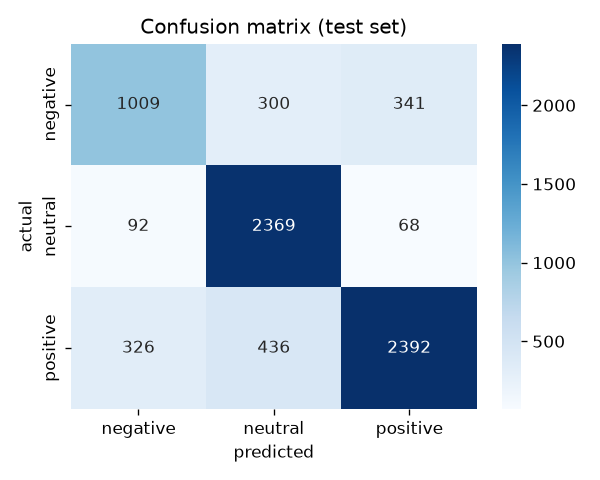

$ git add -A && git commit -qm 'pipeline: first full run' && git log --oneline
86dc038 pipeline: first full run


In [6]:
info = json.load(open("experiment_info.json"))
print(json.dumps(info, indent=1))
from IPython.display import Image, display
display(Image("reports/confusion_matrix.png", width=380))
sh("git add -A && git commit -qm 'pipeline: first full run' && git log --oneline")

## 4 · Caching: re-run only what changed

In [7]:
sh("dvc repro", tail=10)          # nothing changed → every stage is skipped

$ dvc repro


Stage 'data_ingestion' didn't change, skipping
Stage 'data_preprocessing' didn't change, skipping
Stage 'model_building' didn't change, skipping
Stage 'model_evaluation' didn't change, skipping
Stage 'model_registration' didn't change, skipping
Data and pipelines are up to date.


In [8]:
# change one hyper-parameter: only model_building and later stages are out of date
params = open("params.yaml").read()
open("params.yaml", "w").write(params.replace("n_estimators: 367", "n_estimators: 150"))
sh("dvc status")
sh("dvc params diff")
t0 = time.time()
sh("dvc repro", tail=25)
print(f"\n⏱ {time.time() - t0:.0f}s (ingestion and preprocessing were skipped)")
info_150 = json.load(open("experiment_info.json"))
print(f"accuracy with n_estimators=150: {info_150['accuracy']:.4f}  vs 367: {info['accuracy']:.4f}")

$ dvc status


model_building:
	changed deps:
		params.yaml:
			modified:           model_building
$ dvc params diff


Path         Param                        HEAD    workspace
params.yaml  model_building.n_estimators  367     150
$ dvc repro


> python src/model/model_evaluation.py
🏃 View run lightgbm-tfidf-pipeline at: http://127.0.0.1:5050/#/experiments/7/runs/1b52df1eb39745a5b0766a35bcce1bde
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/7
Updating lock file 'dvc.lock'

Running stage 'model_registration':
> python src/model/register_model.py
Updating lock file 'dvc.lock'

To track the changes with git, run:

	git add dvc.lock

To enable auto staging, run:

	dvc config core.autostage true
Use `dvc push` to send your updates to remote storage.
2026-09-17 00:49:31,831 | model_building | INFO | TF-IDF matrix: (29329, 1000)
2026-09-17 00:49:33,212 | model_building | INFO | after SMOTE: 37848 rows, class counts={1: 12616, 0: 12616, -1: 12616}
2026-09-17 00:49:37,188 | model_building | INFO | saved lgbm_model.pkl and tfidf_vectorizer.pkl
2026-09-17 00:49:45,345 | model_evaluation | INFO | accuracy=0.7924 macro_f1=0.7737 run=1b52df1eb39745a5b0766a35bcce1bde
Registered model 'yt_chrome_plugin_model' already exists. Crea

In [9]:
# undo the change: DVC's run-cache restores the old outputs without retraining.
# But model_registration has a side effect (it writes to the MLflow registry), and DVC can't undo that.
# It re-runs, and the registry gets a *third* version that points to the first run's model.
sh("git checkout -- params.yaml")
sh("dvc repro", tail=25)
sh("git status --short")

$ git checkout -- params.yaml

$ dvc repro


Stage 'data_ingestion' didn't change, skipping
Stage 'data_preprocessing' didn't change, skipping
Stage 'model_building' is cached - skipping run, checking out outputs
Updating lock file 'dvc.lock'

Stage 'model_evaluation' is cached - skipping run, checking out outputs
Updating lock file 'dvc.lock'

Running stage 'model_registration':
> python src/model/register_model.py
Updating lock file 'dvc.lock'

To track the changes with git, run:

	git add dvc.lock

To enable auto staging, run:

	dvc config core.autostage true
Use `dvc push` to send your updates to remote storage.
Registered model 'yt_chrome_plugin_model' already exists. Creating a new version of this model...
2026/09/17 00:49:48 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: yt_chrome_plugin_model, version 3
Created version '3' of model 'yt_chrome_plugin_model'.
2026-09-17 00:49:48,180 | register_model | INFO | registered yt_chrome_plugin_model v3 (a

## 5 · Model registry: versions and aliases
The video (MLflow 2.x) moves a version to the **Staging** stage. MLflow 3 replaces stages with **aliases**:
free-form, movable pointers such as `@staging` and `@production`.

In [10]:
NAME = "yt_chrome_plugin_model"
rows = []
for v in sorted(mlflow_client.search_model_versions(f"name='{NAME}'"), key=lambda v: int(v.version)):
    run = mlflow_client.get_run(v.run_id)
    rows.append({"version": v.version, "run_id": v.run_id[:8],
                 "n_estimators": run.data.params.get("model_building.n_estimators"),
                 "accuracy": round(run.data.metrics["accuracy"], 4),
                 "aliases": mlflow_client.get_model_version(NAME, v.version).aliases})
import pandas as pd
pd.DataFrame(rows)

,version,run_id,n_estimators,accuracy,aliases
0,1,a26c75d6,367,0.7869,[]
1,2,1b52df1e,150,0.7924,[]
2,3,a26c75d6,367,0.7869,[staging]


In [11]:
# promote: the version with the best accuracy gets @production (in the video: "transition to Production")
best = max(rows, key=lambda r: (r["accuracy"], -int(r["version"])))
mlflow_client.set_registered_model_alias(NAME, "production", best["version"])
print(f"@production → v{best['version']}   @staging → v{mlflow_client.get_model_version_by_alias(NAME, 'staging').version}")
# note: n_estimators=150 scored slightly higher than the course's 367 on this split. Small differences like this
# are why a promotion rule (e.g. "beats production by > X on a fixed test set") is better than eyeballing.

@production → v2   @staging → v3


## 6 · Run the Flask API and call it (Postman in the video)
The API loads `models:/yt_chrome_plugin_model@staging` from the registry and the vectorizer from `tfidf_vectorizer.pkl`.
It runs on **port 5001** because macOS AirPlay already uses 5000.

In [12]:
API_PORT = 5001
API = f"http://127.0.0.1:{API_PORT}"
subprocess.run(["pkill", "-f", "flask_api/app.py"])
api_log = open("logs/api.txt", "w")
api_proc = subprocess.Popen([sys.executable, "flask_api/app.py"], env={**ENV, "PORT": str(API_PORT)},
                            stdout=api_log, stderr=subprocess.STDOUT, start_new_session=True)
for _ in range(120):
    try:
        print(urllib.request.urlopen(API + "/", timeout=1).read().decode()); break
    except Exception:
        time.sleep(0.5)

def post(path, payload):
    req = urllib.request.Request(API + path, data=json.dumps(payload).encode(), headers={"Content-Type": "application/json"})
    with urllib.request.urlopen(req, timeout=60) as r:
        return r.headers.get_content_type(), r.read()

{"message":"YouTube Sentiment Insights API","model_source":"mlflow registry: yt_chrome_plugin_model@staging"}



In [13]:
ctype, body = post("/predict", {"comments": [
    "This video is awesome! I loved it a lot",
    "Very bad explanation. poor video",
    "the tutorial starts at minute five",
    "I don't think this is not helpful",
]})
pd.DataFrame(json.loads(body))

,comment,label,sentiment
0,This video is awesome! I loved it a lot,positive,1
1,Very bad explanation. poor video,negative,-1
2,the tutorial starts at minute five,neutral,0
3,I don't think this is not helpful,neutral,0


The last example is a double negative (*"don't … not helpful"*), which is hard for a bag-of-n-grams model.
Short, sarcastic or double-negative comments are the typical failure cases.

demo comments: 99
positive    51
neutral     37
negative    11
Name: count, dtype: int64


api_pie.png image/png 25415 bytes


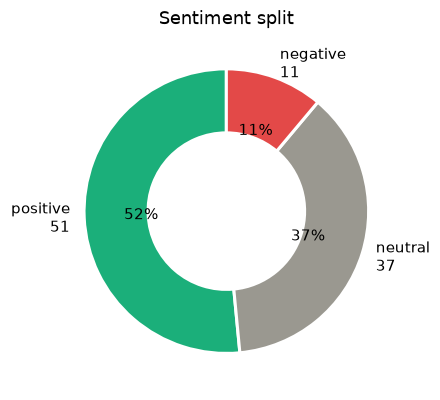

api_trend.png image/png 26392 bytes


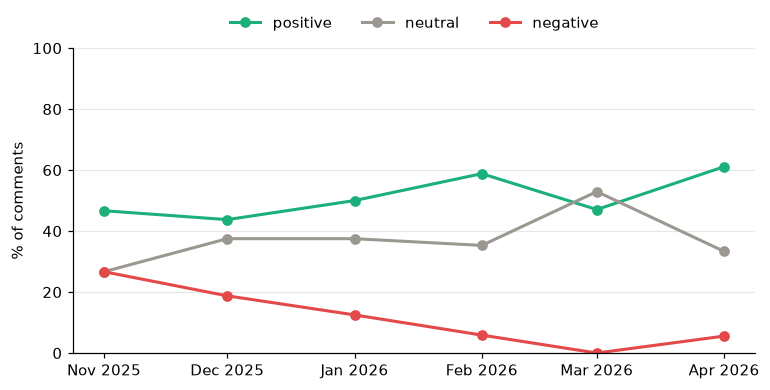

api_wordcloud.png image/png 166881 bytes


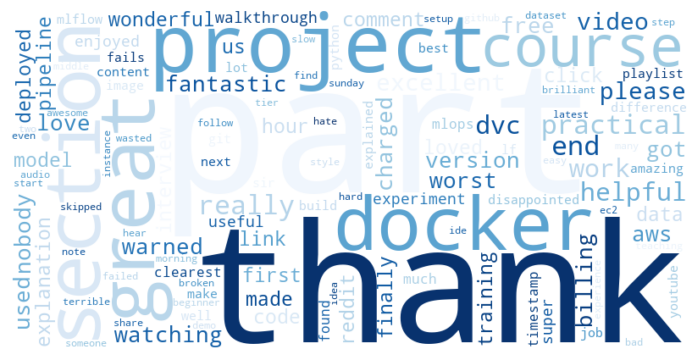

In [14]:
demo = json.load(open("yt_chrome_plugin_frontend/dev/sample_comments.json"))   # fake YouTube-style comments
_, body = post("/predict_with_timestamps", {"comments": [{"text": c["text"], "timestamp": c["timestamp"]} for c in demo]})
preds = json.loads(body)
counts = pd.Series([p["sentiment"] for p in preds]).value_counts().reindex([1, 0, -1], fill_value=0)
print("demo comments:", len(preds)); print(counts.rename({1: "positive", 0: "neutral", -1: "negative"}))

images = {
    "api_pie.png": post("/generate_chart", {"sentiment_counts": {str(k): int(v) for k, v in counts.items()}}),
    "api_trend.png": post("/generate_trend_graph", {"sentiment_data": preds}),
    "api_wordcloud.png": post("/generate_wordcloud", {"comments": [c["text"] for c in demo]}),
}
for fname, (ctype, data) in images.items():
    open(f"reports/{fname}", "wb").write(data)
    print(fname, ctype, len(data), "bytes")
    display(Image(data=data, width=420))
json.dump({"counts": {int(k): int(v) for k, v in counts.items()}, "n": len(preds)}, open("reports/api_demo_counts.json", "w"))

The extension's popup shows the same results. To see the real popup without a YouTube API key, open
`yt_chrome_plugin_frontend/dev_preview.html` in a browser while the API is running. It uses the fake comments above.

## 7 · Automated tests

In [15]:
sh(f"{sys.executable} -m pytest -q tests", tail=15)

$ /Users/hemanthreddy/Desktop/data_science/MLOps/projects/.venv/bin/python3.13 -m pytest -q tests


.....                                                                    [100%]
5 passed in 2.95s


## 8 · Docker image  (the full deployment is in Chapter 18)

In [16]:
DOCKER = shutil.which("docker")
if DOCKER and subprocess.run([DOCKER, "info"], capture_output=True).returncode == 0:
    sh("docker build -t yt-sentiment-api .", tail=10)
    sh("docker run -d --rm --name yt-sentiment -p 8080:8080 yt-sentiment-api")
    time.sleep(8)
    print(urllib.request.urlopen("http://127.0.0.1:8080/").read().decode())
    sh("docker stop yt-sentiment")
else:
    print("⏭ Docker isn't running here. Commands to run once it is:")
    print("   docker build -t yt-sentiment-api .")
    print("   docker run -d -p 8080:8080 yt-sentiment-api     # then open http://localhost:8080/")
print(open("Dockerfile").read())

⏭ Docker isn't running here. Commands to run once it is:
   docker build -t yt-sentiment-api .
   docker run -d -p 8080:8080 yt-sentiment-api     # then open http://localhost:8080/
# Backend image for the YouTube Sentiment Insights extension.
# The course uses python:3.8-slim-buster; both 3.8 and Debian buster are end-of-life, so this uses 3.11-slim.
FROM python:3.11-slim

# LightGBM needs the OpenMP runtime
RUN apt-get update && apt-get install -y --no-install-recommends libgomp1 \
    && rm -rf /var/lib/apt/lists/*

WORKDIR /app

COPY requirements-api.txt .
RUN pip install --no-cache-dir -r requirements-api.txt \
    && python -m nltk.downloader -d /usr/local/share/nltk_data stopwords wordnet omw-1.4

# only what the API needs at runtime
COPY src/__init__.py src/common.py src/
COPY flask_api/ flask_api/
COPY lgbm_model.pkl tfidf_vectorizer.pkl ./

EXPOSE 8080
# gunicorn instead of Flask's development server
CMD ["gunicorn", "--bind", "0.0.0.0:8080", "--workers", "2", "--timeout", "12

## 9 · Shut down

In [17]:
api_proc.terminate()
stop_mlflow_server()
sh("dvc dag --md", tail=30)
print("API and MLflow server stopped. To restart the UI:  mlflow server --backend-store-uri sqlite:///mlflow.db --artifacts-destination ./mlartifacts --port 5050")

$ dvc dag --md


```mermaid
flowchart TD
	node1["data_ingestion"]
	node2["data_preprocessing"]
	node3["model_building"]
	node4["model_evaluation"]
	node5["model_registration"]
	node1-->node2
	node2-->node3
	node2-->node4
	node3-->node4
	node4-->node5
```
API and MLflow server stopped. To restart the UI:  mlflow server --backend-store-uri sqlite:///mlflow.db --artifacts-destination ./mlartifacts --port 5050
